In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os

os.chdir("..")

In [82]:
from aether.clause.nodes.nodes import SMA
from aether.clause.nodes.nodes import ADD
from aether.clause.nodes.nodes import SHIFT
from aether.clause.nodes.nodes import DIFF
from aether.clause.nodes.nodes import PctChange
from aether.clause.nodes.nodes import ABS
from aether.clause.nodes.nodes import DIV
from aether.clause.nodes.nodes import SUB
from aether.clause.nodes.nodes import Comparison
from aether.clause.nodes.nodes import NewHigh
from aether.clause.nodes.nodes import NewLow
from aether.clause.nodes.nodes import ZSCORE
from aether.clause.nodes.nodes import MAX
from aether.clause.nodes.nodes import MIN
from aether.clause.nodes.nodes import STD
from aether.clause.nodes.nodes import SKEW
from aether.clause.nodes.nodes import KURT
from aether.clause.nodes.nodes import DATA
from aether.clause.nodes.nodes import UpStreak
from aether.clause.nodes.nodes import DownStreak
from aether.clause.nodes.nodes import MeanRevertKick
from aether.clause.nodes.nodes import PullbackWithinBand
from aether.clause.nodes.nodes import DrawdownExceed
from aether.clause.nodes.nodes import JumpDetect
from aether.clause.nodes.nodes import ZBetween
from aether.clause.nodes.nodes import EqualApprox
from aether.clause.nodes.nodes import ZEXP
from aether.clause.nodes.nodes import ZSigmoid
from aether.clause.nodes.nodes import CrossDown
from aether.clause.nodes.nodes import CrossUp
from aether.clause.nodes.nodes import SlopeSignChange

from aether.clause.tree.generator import ClauseGenerator
from aether.clause.graph.extractor import SubgraphExtractor
from aether.clause.graph.edge import SUEdgeCalculator
from aether.clause.graph.base import ClauseGraph
from aether.utils import generate_uuid
from aether.utils import draw_graph

In [8]:
# 모든 노드들의 인스턴스를 포함한 리스트
nodes = [
    # 기본 수학 연산 노드들
    ADD(),
    DIV(), 
    SUB(),
    ABS(),
    SMA(period=10),
    SHIFT(period=10),
    DIFF(period=10),
    PctChange(period=10),
    STD(period=10),
    NewHigh(period=10),
    NewLow(period=10),
    MAX(period=10),
    MIN(period=10),
    ZSCORE(period=10), 
    SKEW(period=10),
    KURT(period=10),
    ZEXP(period=10),
    ZSigmoid(period=10),

    # 루트 노드들 
    Comparison(),
    ZBetween(period=10, lo=-1.5, hi=1.5),
    EqualApprox(tol=1e-2),
    CrossUp(),
    CrossDown(),
    SlopeSignChange(p=10),
    UpStreak(p=10),
    DownStreak(p=10),
    MeanRevertKick(p=10, z_th=1.0, dmax=10, eps=0.01),
    PullbackWithinBand(p=10, k=0.5),
    DrawdownExceed(pct=0.1, lookback=10),
    JumpDetect(p=10, q_tail=0.1),
    
    # 데이터 노드들 (label 파라미터 필요)
    DATA("OPEN", "BTCUSDT"),
    DATA("HIGH", "BTCUSDT"), 
    DATA("LOW", "BTCUSDT"),
    DATA("CLOSE", "BTCUSDT"),
    DATA("VOLUME", "BTCUSDT"),
]

Loading dataframes ...: 100%|██████████| 80/80 [00:01<00:00, 70.29it/s] 


In [9]:
generator = ClauseGenerator(nodes)

In [10]:
tree = generator.generate(max_depth=3)

tree.iscompleted, tree.depth

(True, 4)

In [11]:
trees = []

while len(trees) < 2:
    tree = generator.generate(max_depth=3)

    if tree.depth == 3 and tree.iscompleted:
        trees.append(tree)

In [12]:
tree_a, tree_b = trees

In [13]:
print(tree_a)

print(tree_b)

NewLow(10)
└── PctChange(10)
    └── SKEW(10)
        └── DATA[HIGH]
NewHigh(10)
└── ZEXP(10)
    └── SMA(10)
        └── DATA[CLOSE]


In [14]:
result_a = tree_a.evaluate()

result_b = tree_b.evaluate()

In [15]:
result_a.value_counts()

HIGH
False    34795
True      4589
Name: count, dtype: int64

In [16]:
result_b.value_counts()

CLOSE
False    30772
True      8612
Name: count, dtype: int64

In [17]:
SUEdgeCalculator.calculate(
    series_a = result_a,
    series_b = result_b,
    alpha = 0.0,
)

0.0002708494841700942

## Graph

In [18]:
# 2. Generate Multiple ClauseTrees
trees = []
n_trees = 8
depth = 3

while len(trees) < n_trees:

    tree = generator.generate(max_depth=depth)
    tree_id = generate_uuid()
    tree.name = tree_id

    if tree.iscompleted and tree.depth == depth:
        trees.append(tree)

In [19]:
clause_graph = ClauseGraph(name = "Graph")
clause_graph.set_edge_calculator(SUEdgeCalculator.calculate)

2025-10-03 23:30:04 - aether.clause.graph.base - INFO - Edge calculator set


In [20]:
ids = clause_graph.add_clause_trees(trees)

2025-10-03 23:30:05 - aether.clause.graph.base - INFO - Added ClauseTree as node id: 1cc5acd4
2025-10-03 23:30:05 - aether.clause.graph.base - INFO - Added ClauseTree as node id: 759bb1ce
2025-10-03 23:30:05 - aether.clause.graph.base - INFO - Added ClauseTree as node id: 4aab58e4
2025-10-03 23:30:05 - aether.clause.graph.base - INFO - Added ClauseTree as node id: 11dede54
2025-10-03 23:30:05 - aether.clause.graph.base - INFO - Added ClauseTree as node id: df33f9f0
2025-10-03 23:30:05 - aether.clause.graph.base - INFO - Added ClauseTree as node id: b5ba1bab
2025-10-03 23:30:05 - aether.clause.graph.base - INFO - Added ClauseTree as node id: 480fe4e3
2025-10-03 23:30:05 - aether.clause.graph.base - INFO - Added ClauseTree as node id: 51cacfe5


In [21]:
clause_graph.compute_all_edges()

2025-10-03 23:30:06 - aether.clause.graph.base - INFO - Added 28 edges with threshold 0.0


In [22]:
clause_graph.num_nodes

8

In [23]:
clause_graph.num_edges

28

In [24]:
clause_graph

ClauseGraph(8 nodes)

In [25]:
clause_graph.clause_trees

{'1cc5acd4': <aether.clause.tree.base.ClauseTree at 0x12c4a76d0>,
 '759bb1ce': <aether.clause.tree.base.ClauseTree at 0x12c026790>,
 '4aab58e4': <aether.clause.tree.base.ClauseTree at 0x12a5f5650>,
 '11dede54': <aether.clause.tree.base.ClauseTree at 0x12c4b15d0>,
 'df33f9f0': <aether.clause.tree.base.ClauseTree at 0x12c026a50>,
 'b5ba1bab': <aether.clause.tree.base.ClauseTree at 0x12c4b36d0>,
 '480fe4e3': <aether.clause.tree.base.ClauseTree at 0x12c4b3810>,
 '51cacfe5': <aether.clause.tree.base.ClauseTree at 0x12c4b4350>}

In [27]:
clause_graph.get_neighbors(node_id = '1cc5acd4')

['759bb1ce',
 '4aab58e4',
 '11dede54',
 'df33f9f0',
 'b5ba1bab',
 '480fe4e3',
 '51cacfe5']

In [46]:
clause_graph.clause_trees

{'1cc5acd4': <aether.clause.tree.base.ClauseTree at 0x12c4a76d0>,
 '759bb1ce': <aether.clause.tree.base.ClauseTree at 0x12c026790>,
 '4aab58e4': <aether.clause.tree.base.ClauseTree at 0x12a5f5650>,
 '11dede54': <aether.clause.tree.base.ClauseTree at 0x12c4b15d0>,
 'df33f9f0': <aether.clause.tree.base.ClauseTree at 0x12c026a50>,
 'b5ba1bab': <aether.clause.tree.base.ClauseTree at 0x12c4b36d0>,
 '480fe4e3': <aether.clause.tree.base.ClauseTree at 0x12c4b3810>,
 '51cacfe5': <aether.clause.tree.base.ClauseTree at 0x12c4b4350>}

In [28]:
extractor = SubgraphExtractor(clause_graph)

In [55]:
extractor.graph.clause_trees

{'1cc5acd4': <aether.clause.tree.base.ClauseTree at 0x12c4a76d0>,
 '759bb1ce': <aether.clause.tree.base.ClauseTree at 0x12c026790>,
 '4aab58e4': <aether.clause.tree.base.ClauseTree at 0x12a5f5650>,
 '11dede54': <aether.clause.tree.base.ClauseTree at 0x12c4b15d0>,
 'df33f9f0': <aether.clause.tree.base.ClauseTree at 0x12c026a50>,
 'b5ba1bab': <aether.clause.tree.base.ClauseTree at 0x12c4b36d0>,
 '480fe4e3': <aether.clause.tree.base.ClauseTree at 0x12c4b3810>,
 '51cacfe5': <aether.clause.tree.base.ClauseTree at 0x12c4b4350>}

In [75]:
subgraph = extractor.extract(size = 3, start_node = '759bb1ce')

2025-10-04 13:37:48 - aether.clause.graph.extractor - INFO - Random walk completed. Final size: 3
2025-10-04 13:37:48 - aether.clause.graph.base - INFO - Added ClauseTree as node id: 4aab58e4
2025-10-04 13:37:48 - aether.clause.graph.base - INFO - Added ClauseTree as node id: 1cc5acd4
2025-10-04 13:37:48 - aether.clause.graph.base - INFO - Added ClauseTree as node id: 759bb1ce
2025-10-04 13:37:48 - aether.clause.graph.base - INFO - Added edge between 4aab58e4 and 1cc5acd4


2025-10-04 13:37:48 - aether.clause.graph.base - INFO - Added edge between 4aab58e4 and 759bb1ce
2025-10-04 13:37:48 - aether.clause.graph.base - INFO - Added edge between 1cc5acd4 and 759bb1ce


In [81]:
subgraph.clause_trees

{'4aab58e4': <aether.clause.tree.base.ClauseTree at 0x12a5f5650>,
 '1cc5acd4': <aether.clause.tree.base.ClauseTree at 0x12c4a76d0>,
 '759bb1ce': <aether.clause.tree.base.ClauseTree at 0x12c026790>}

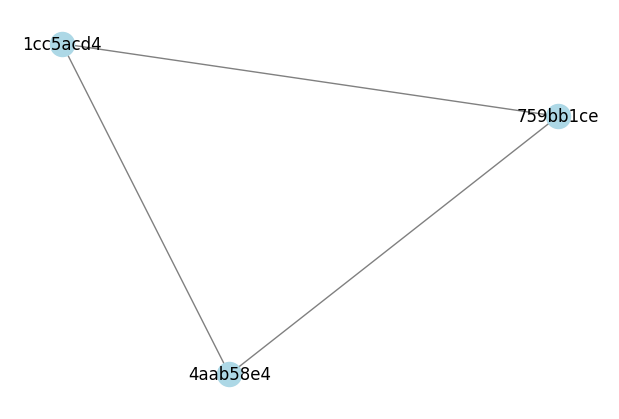

In [87]:
draw_graph(subgraph.graph)